# College to Pro: An NFL Draft Prospect Analysis

### Isaac Marr

A similarity-search and clustering analysis of NFL quarterback draft prospects: comparing college performance and career outcomes to find historical "comps" for future prospects, and to surface the traits that separate NFL hits from busts.

# Executive Summary

The goal of this project is to find a reliable method to match college quarterbacks with similar players to get a sense of possible career outcomes. Being able to find clusters or perform similarity searches of players could help find quarterbacks with top-tier talent who are not being drafted highly. It could also help avoid quarterbacks who could underperform their draft position.

I combined three different datasets for this project: a dataset with the stats of every college quarterback who registered a statistic between 2004 and 2020, a dataset containing every NFL quarterback who entered the league between 2005 and 2021 for results, and NFL combine data from 2000 to 2025. The NFL Combine data was too sparse to ultimately use in my analysis, so I dropped it during clustering.

To prepare this data, I first merged the datasets. I then unskewed several columns and standardized the data on a zero-to-one scale. I used **FeatureHasher** from scikit-learn to hash the categorical columns, then used **PCA** to reduce the dimensionality of the hashed data.

I then applied clustering to the dataset using several different methods. I tried **agglomerative clustering**, **spectral clustering**, and **OPTICS**. Spectral clustering produced a cluster with a high success rate that I then did some additional analysis on.

Finally, I conducted a **similarity search using a flat index**. I wrote a function that allows you to search for any quarterback in the dataset and return the top five most similar quarterbacks. Because the dataset was small enough to use a flat index without running into speed or memory issues, recall was 100%.

Overall, I accomplished my goal of a reliable method to match college quarterbacks with similar players. I located a cluster of high-performing quarterbacks that I can continue to analyze, and built a working similarity search function that performs well from a recall perspective and also produces results that match my domain knowledge.

# 1.0 Introduction

According to [The Athletic](https://www.nytimes.com/athletic/5377539/2024/03/29/odds-a-top-10-qb-busts-scoop-city/), 41% of quarterbacks drafted in the first round of the NFL Draft can be classified as a reach or a bust. Quarterback is the most important position in football, and NFL teams pay handsomely for good ones, with top QBs making more than $50 million per year according to [Spotrac](https://www.spotrac.com/nfl/rankings/player/_/year/2024/position/qb/sort/contract_average). Even a mediocre quarterback is often the "face of the franchise" as long as he is playing, and the drafting of a new quarterback is always a momentous occasion for the fanbase. Multi-billion dollar companies like NFL teams rarely make decisions based on a coin flip, but drafting a good quarterback has only slightly better odds. A solid quarterback can boost ticket and merchandise sales, a great one can bring a Super Bowl and even shift the financial fortunes of his host city. With this project, I look at every quarterback who played a college snap from 2004 until 2020 and track their college stats, draft position, and NFL success. Using this data, I develop similarity measures to compare future potential draft picks to past players, and explore cluster analysis to see which traits generally lead to NFL success.

# 2.0 Data

I am using three datasets that I have merged for this project.

1. I used the [cfbfastR](https://cfbfastr.sportsdataverse.org) R package to get a dataset with the stats of every college quarterback who registered a statistic between 2004 (the earliest year the package can return) and 2020. I chose 2020 because I wanted a minimum of four seasons of NFL data to study outcomes.
2. I used the [nflreadr](https://nflreadr.nflverse.com/reference/index.html) R package to get NFL combine data from 2000 to 2025. The NFL Combine is a yearly event where the top college players are invited to Indianapolis to work out for NFL teams, competing in the bench press, 40-yard dash, vertical jump, and more.
3. I used the [Pro Football Reference](https://www.pro-football-reference.com) StatHead draft tools to generate a spreadsheet containing every NFL quarterback who entered the league between 2005 and 2021, with their draft position and some statistics. I use Football Reference's AV metric to judge career quality; you can read about that metric [here](https://www.pro-football-reference.com/about/approximate_value.htm).

See the appendix for an explanation of each column used in the final analysis. All of the cleaning, feature engineering, clustering, and similarity-search logic below lives in the reusable `src/qb_similarity` package so it can be reused outside this notebook (e.g. in `app.py`).

# 3.0 Data Loading and Cleaning

In [1]:
import os

# faiss and numba (a UMAP dependency) each bundle their own OpenMP runtime, which can
# segfault on macOS when both spin up worker threads in the same process. Capping thread
# counts and forcing numba off the OpenMP threading layer avoids the conflict.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("NUMBA_THREADING_LAYER", "workqueue")

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from qb_similarity import data_loading, cleaning, features, clustering, similarity, viz

Loading the three raw datasets and running them through the cleaning/merge pipeline in `qb_similarity.cleaning`.

In [2]:
results_df, cfb_df, combine_df = data_loading.load_raw_data()
print(results_df.shape, cfb_df.shape, combine_df.shape)

(212, 16) (10350, 62) (8649, 18)


I calculated AV per year so that quarterbacks with ongoing careers wouldn't be penalized by using cumulative AV. In the end I used cumulative AV (with a threshold) to define NFL success, but per-year AV remains in the dataset for future analysis.

The college data has columns for statistics from every position. I dropped any columns unrelated to quarterbacking, aggregated each player's season-level rows into one row per career, and computed rate stats (completion %, yards per attempt, etc.) plus a passer rating. Notice that the NFL dataset is only ~200 players, whereas the college dataset is over 10,000 rows of season data — that really shows how tough it is to make the NFL even as a high-level college athlete.

Passer rating is an imperfect stat, but it's a simple way to look at overall efficiency. I tried to pull advanced statistics using the R package, but there wasn't enough data — many advanced stats only started being recorded in the past few years.

In [3]:
cfb_nfl_dataset = cleaning.build_cfb_nfl_dataset(results_df, cfb_df, combine_df)
print(cfb_nfl_dataset.shape)
cfb_nfl_dataset.head()

(1046, 42)


,athlete_id,passing_completions,passing_att,passing_yds,passing_td,passing_int,rushing_car,rushing_yds,rushing_td,rushing_long,...,years_played,av_per_year,combine_season,ht,wt,forty,vertical,broad_jump,cone,shuttle
0,132870,128.0,222.0,1730.0,14.0,3.0,78.0,358.0,1.0,36.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,136354,114.0,203.0,1263.0,9.0,4.0,34.0,18.0,2.0,15.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,160307,833.0,1271.0,10614.0,88.0,39.0,170.0,193.0,6.0,31.0,...,1.0,1.0,2010.0,6-1,209.0,4.84,32.0,102.0,7.07,4.35
4,160603,119.0,209.0,1427.0,7.0,5.0,127.0,375.0,3.0,21.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,162068,104.0,209.0,1304.0,12.0,4.0,55.0,90.0,3.0,20.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


I filtered the college QBs down to those who threw at least 100 career passes — there were too many quarterbacks in the dataset with very little data, which made analysis difficult. I also dropped one ambiguous duplicate name, since I couldn't tell whether it was the same player appearing twice or two different players who happen to share a name.

# 4.0 Exploratory Data Analysis

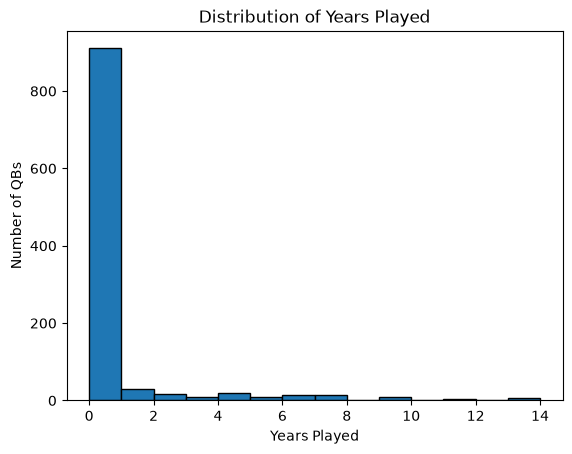

In [4]:
viz.plot_years_played_distribution(cfb_nfl_dataset)
plt.show()

The vast majority of college quarterbacks never play in the NFL. This also signals that there's likely a lot of skew across the dataset, which I'll need to address before clustering.

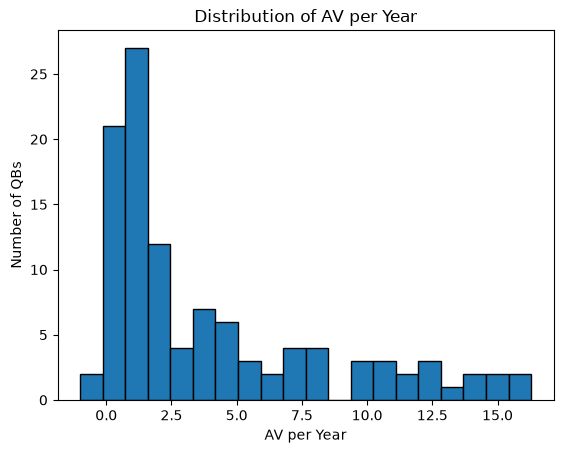

In [5]:
viz.plot_av_per_year_distribution(cfb_nfl_dataset)
plt.show()

Most quarterbacks who do make the NFL don't make much of an impact. A negative value is possible (and visible here) — only the very worst quarterbacks accumulate negative AV.

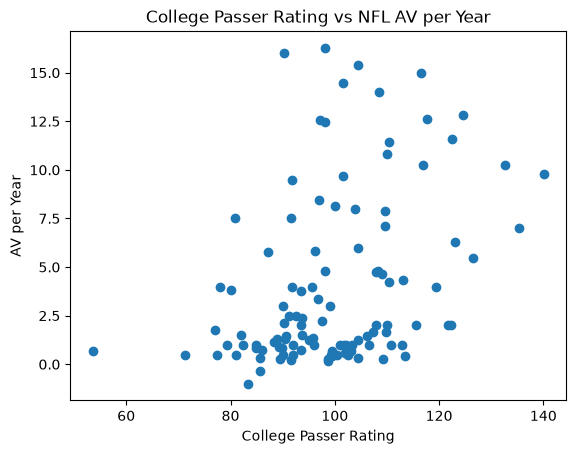

In [6]:
viz.plot_passer_rating_vs_av(cfb_nfl_dataset)
plt.show()

There could be a small correlation between college passer rating and NFL success — a combination of efficiency stats translating well to the next level would make sense.

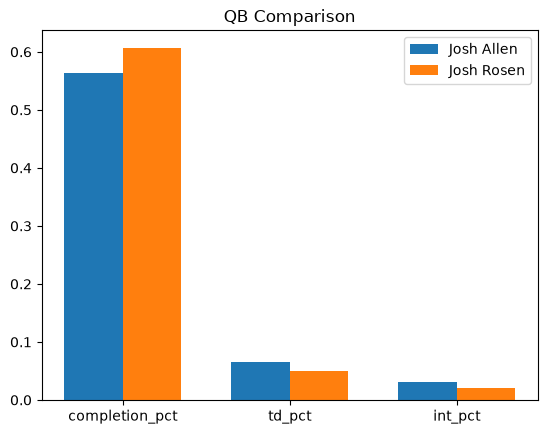

In [7]:
viz.plot_qb_comparison(cfb_nfl_dataset, 'josh allen', 'josh rosen', ['completion_pct', 'td_pct', 'int_pct'])
plt.show()

When plotting some of the components of passer rating for two quarterbacks named Josh from the 2018 draft, the picture gets murkier. Allen won league MVP, while Rosen is a notorious bust — yet Rosen looks like the better prospect on two key statistics: completion percentage and interception percentage (lower is better). Simple box-score stats alone aren't enough here; we have to go beyond them.

# 5.0 Prepping Data for Cluster Analysis and More EDA

In [8]:
standard_data = features.build_standard_data(cfb_nfl_dataset)
print(standard_data.shape)
standard_data.head()

(1046, 74)


,athlete_id,passing_completions,passing_att,passing_yds,passing_td,passing_int,rushing_car,rushing_yds,rushing_td,rushing_long,...,pca_feature_40,pca_feature_41,pca_feature_42,pca_feature_43,pca_feature_44,pca_feature_45,pca_feature_46,pca_feature_47,pca_feature_48,pca_feature_49
0,132870.0,0.269403,0.062628,0.076738,0.434714,0.055556,0.434976,0.594135,0.173003,0.391304,...,0.015493,-0.001030,-0.012159,-0.001048,0.012129,-0.017166,-0.009517,-0.013171,0.005064,-0.015912
1,136354.0,0.238190,0.052875,0.050034,0.356188,0.074074,0.287292,0.543987,0.271327,0.163043,...,-0.138889,0.044801,0.108283,-0.054496,0.073224,0.122472,0.047671,0.107430,-0.221730,-0.158014
2,160307.0,0.822295,0.601129,0.584744,0.851740,0.722222,0.592929,0.571747,0.470166,0.336957,...,0.001970,0.004884,-0.063274,0.002685,0.023603,-0.031720,-0.033565,0.021631,-0.158502,-0.025404
3,160603.0,0.249717,0.055955,0.059412,0.315234,0.092593,0.531512,0.596346,0.339831,0.228261,...,0.008302,0.001001,-0.064789,-0.011012,0.020016,-0.052938,-0.017557,0.004809,-0.045039,0.020694
4,162068.0,0.213692,0.055955,0.052379,0.406377,0.074074,0.370327,0.556386,0.339831,0.217391,...,0.053224,0.003590,-0.105852,-0.043693,-0.003177,-0.002574,-0.043950,0.017259,-0.012620,0.003997


`build_standard_data` (in `src/qb_similarity/features.py`):
1. Drops NFL outcome columns so results can't leak into the model, and labels each QB with `nfl_success` (career AV ≥ 30).
2. Converts height strings like `"6-0"` to inches.
3. Un-skews any numeric column with `|skew| > 1` using a Yeo-Johnson power transform, then scales everything to 0–1 with `MinMaxScaler`.
4. Feature-hashes `conference` (143 unique values → 128 hashed features) and `college_team` (406 unique values → 256 hashed features), then reduces the combined 384 hashed columns to 50 with PCA so they don't overwhelm the rest of the feature set.
5. Fills missing combine measurements with -1 — I'm skeptical this column will be very useful, since there are so many missing values relative to how many quarterbacks attended the combine.

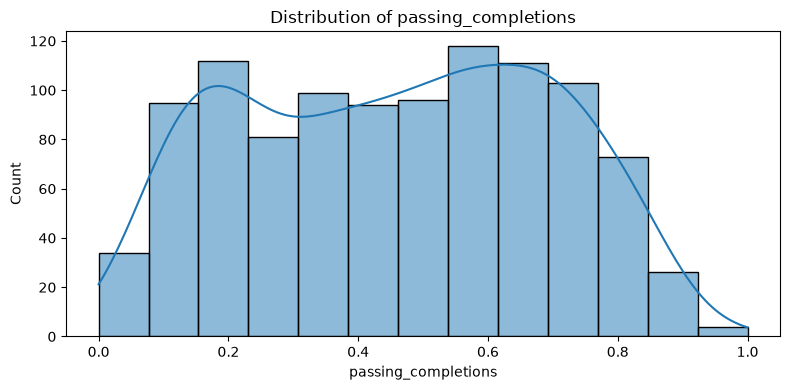

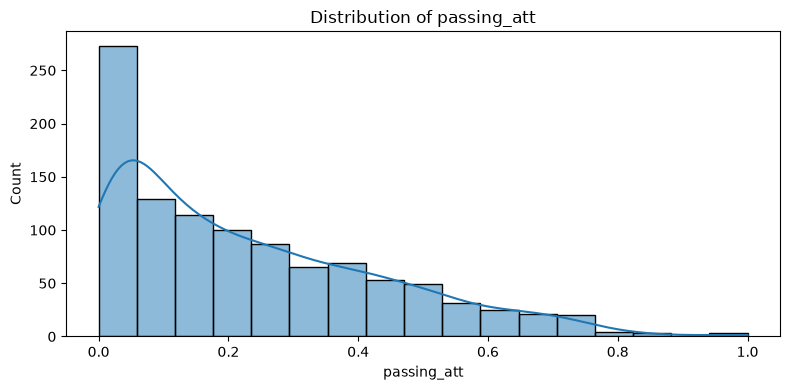

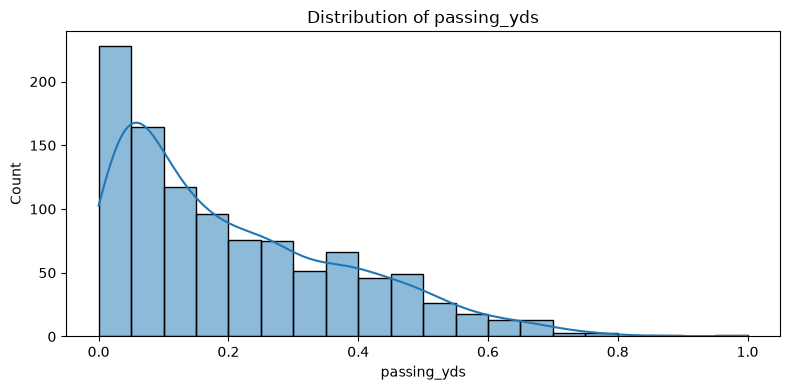

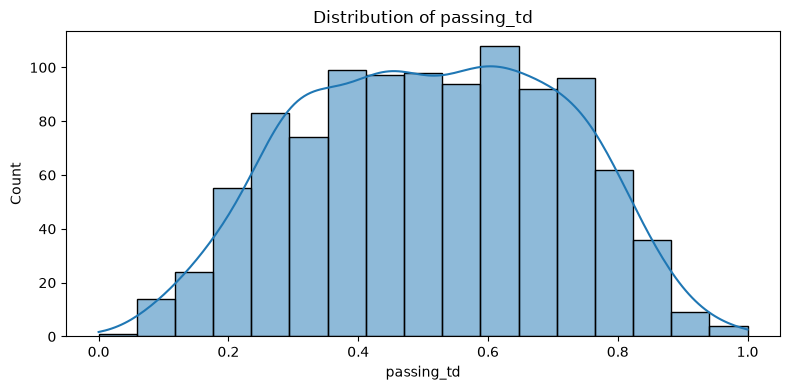

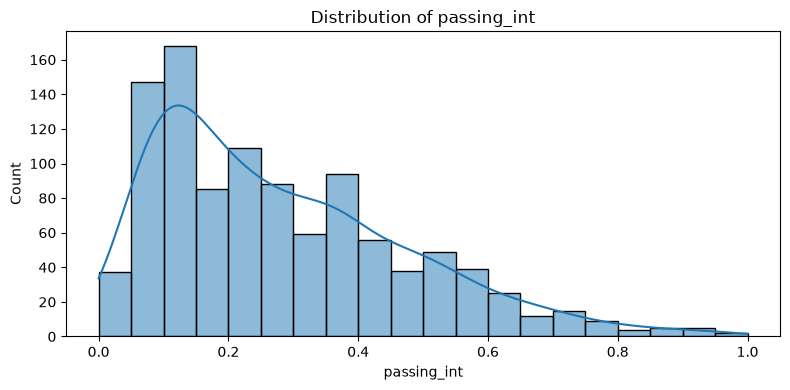

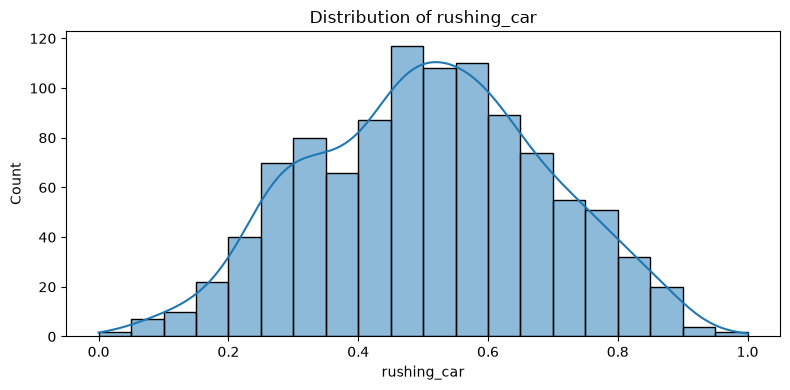

In [9]:
numeric_columns = standard_data.select_dtypes(include='number').columns.tolist()
for col in ['athlete_id', 'nfl_success']:
    if col in numeric_columns:
        numeric_columns.remove(col)

for fig in viz.plot_feature_distributions(standard_data, numeric_columns[:6]):
    plt.show()

Most of the data is skewed to the left, as expected — most quarterbacks post low values across most counting stats. The rate statistics are more normally distributed.

# 6.0 Cluster Analysis

In [10]:
athlete_ids = standard_data['athlete_id'].copy()
cluster_data = standard_data.drop(columns=['athlete_id'])

clustering.compute_eigengap_table(cluster_data)

,Eigenvalues,Eigengaps,Eigengap_Eigenvalue_ratio
0,2.001136,1.790310,0.894647
1,0.210826,0.074310,0.352471
2,0.136516,0.027284,0.199857
3,0.109232,0.015021,0.137511
4,0.094212,0.011486,0.121915
...,...,...,...
68,0.010773,-0.000071,-0.006622
69,0.010844,-0.000100,-0.009221
70,0.010944,-0.000130,-0.011849
71,0.011074,-0.000101,-0.009127


There's a sizeable gap between the first two eigenvalues, which suggests a low number of clusters might fit the data reasonably well.

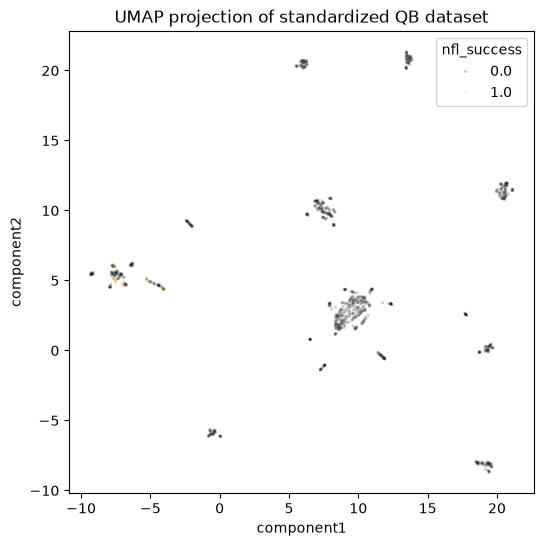

In [11]:
embedding = clustering.umap_embedding(cluster_data)
embedding['nfl_success'] = cluster_data['nfl_success'].values

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=embedding, x='component1', y='component2', hue='nfl_success', style='nfl_success',
                markers=['o', 'v'], s=5, alpha=0.2, ax=ax, palette={0: 'black', 1: 'orange'})
ax.set_title('UMAP projection of standardized QB dataset')
plt.show()

This is an interesting-looking projection — the data is clumped tightly with a lot of distance between clumps. I'll start with agglomerative clustering, since the structure of this plot doesn't look promising for k-means.

cluster_assignments  nfl_success
0                    0.0            859
                     1.0              2
1                    0.0             95
                     1.0             24
2                    0.0             25
                     1.0              7
3                    0.0             30
                     1.0              4
Name: count, dtype: int64


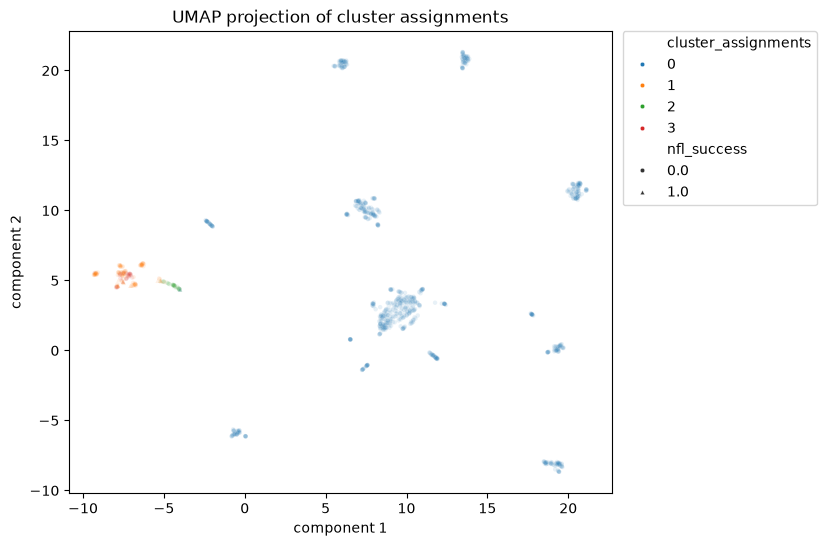

In [12]:
cluster_data = clustering.run_agglomerative(cluster_data, n_clusters=4)
print(cluster_data.loc[:, ['cluster_assignments', 'nfl_success']].value_counts().sort_index(level=0))
viz.plot_cluster_assignments(embedding, cluster_data['cluster_assignments'])
plt.show()

I'm struggling to see any useful pattern here — no cluster has a higher-than-normal share of successful QBs. I don't want to go much further without dropping the combine data, since I'm confident it's hurting the analysis given how sparse it is.

In [13]:
combine_columns = ['ht', 'wt', 'forty', 'vertical', 'broad_jump', 'cone', 'shuttle']
cluster_data = cluster_data.drop(columns=combine_columns + ['cluster_assignments'])

clustering.compute_eigengap_table(cluster_data)

,Eigenvalues,Eigengaps,Eigengap_Eigenvalue_ratio
0,0.268594,0.131876,0.490987
1,0.136718,0.035428,0.259131
2,0.101290,0.015549,0.153513
3,0.085741,0.009824,0.114584
4,0.075916,0.005169,0.068084
...,...,...,...
61,0.010812,-0.000072,-0.006702
62,0.010884,-0.000306,-0.028121
63,0.011190,0.000197,0.017636
64,0.010993,-0.000089,-0.008115


The structure of the eigenvalues is similar, although the magnitudes are now much smaller, and the drop-off after the first value is less extreme.

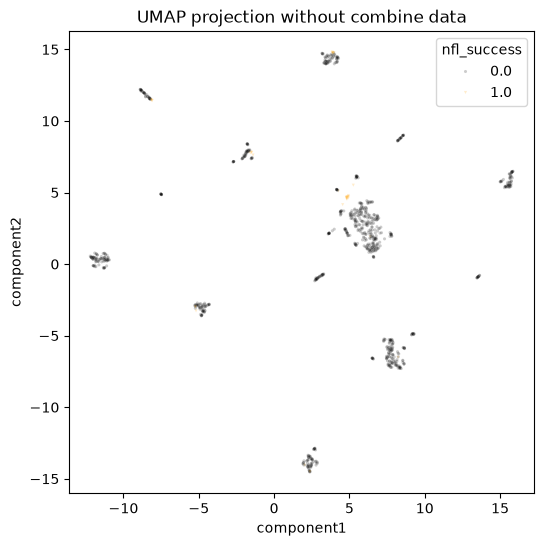

In [14]:
embedding = clustering.umap_embedding(cluster_data)
embedding['nfl_success'] = cluster_data['nfl_success'].values

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=embedding, x='component1', y='component2', hue='nfl_success', style='nfl_success',
                markers=['o', 'v'], s=5, alpha=0.2, ax=ax, palette={0: 'black', 1: 'orange'})
ax.set_title('UMAP projection without combine data')
plt.show()

This projection looks slightly better than before — the clusters are still well defined but a bit less scattered.

cluster_assignments  nfl_success
0                    0.0            451
                     1.0             17
1                    0.0            417
                     1.0              4
2                    0.0            127
                     1.0             15
3                    0.0             14
                     1.0              1
Name: count, dtype: int64


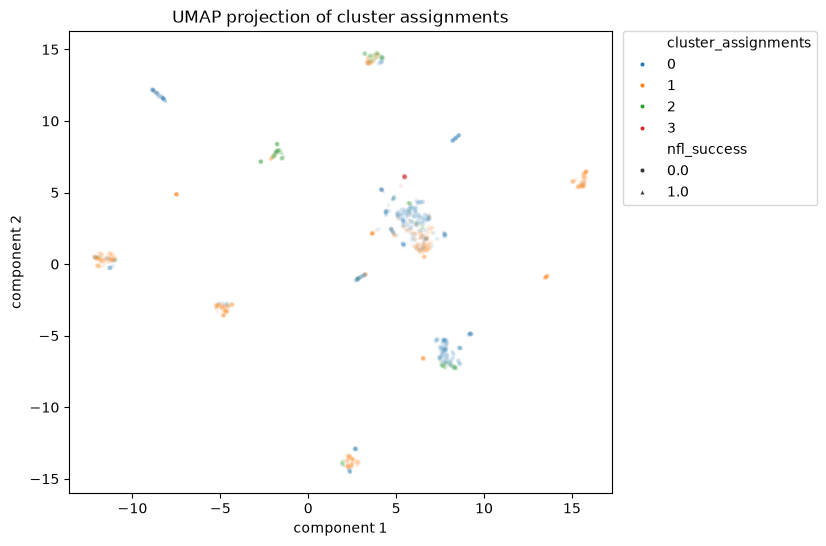

In [15]:
cluster_data = clustering.run_agglomerative(cluster_data, n_clusters=4)
print(cluster_data.loc[:, ['cluster_assignments', 'nfl_success']].value_counts().sort_index(level=0))
viz.plot_cluster_assignments(embedding, cluster_data['cluster_assignments'])
plt.show()

Successful QBs are still spread pretty evenly across clusters — more clusters are likely needed. Below I sweep cluster counts and use silhouette score plus max cluster diameter to pick a better value of k.

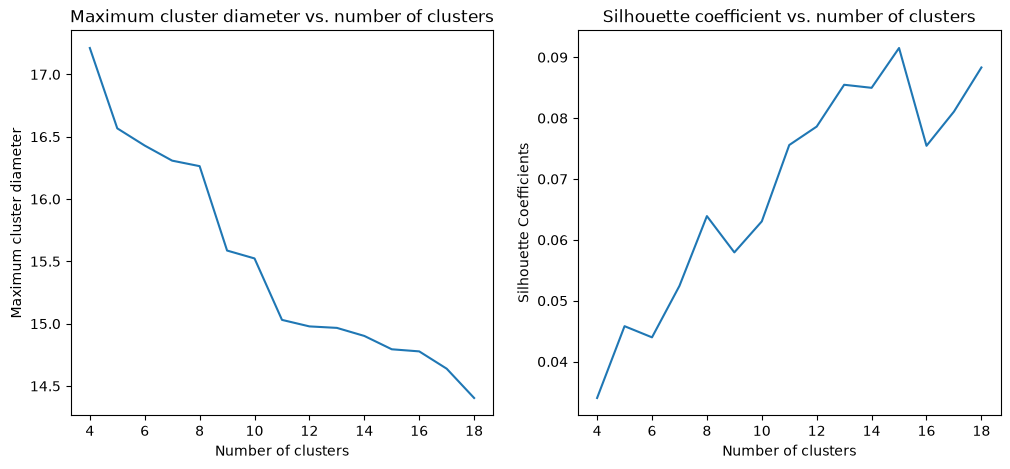

,NumberClusters,ClusterDiameter,SilhouetteCoefficient
0,4,17.211996,0.034023
1,5,16.567228,0.045820
2,6,16.429035,0.043986
3,7,16.308072,0.052442
4,8,16.263954,0.063903
5,9,15.586812,0.057941
6,10,15.523536,0.063034
7,11,15.030508,0.075578
8,12,14.978215,0.078609
9,13,14.966303,0.085476


In [16]:
evaluation = clustering.evaluate_agglomerative_clusters(cluster_data.drop(columns='cluster_assignments'))
viz.plot_agglomerative_evaluation(evaluation)
plt.show()
evaluation

The silhouette coefficient peaks around 15 clusters, and there's a small kink in the cluster-diameter curve there too. I'll try 15 clusters.

cluster_assignments  nfl_success
0                    0.0            226
                     1.0             10
1                    0.0            130
                     1.0              1
2                    0.0             79
                     1.0              6
3                    0.0             14
                     1.0              1
4                    0.0             33
                     1.0              1
5                    0.0             36
                     1.0              6
6                    0.0             24
                     1.0              1
7                    0.0             38
                     1.0              4
8                    0.0            159
                     1.0              1
9                    0.0            112
                     1.0              2
10                   0.0            106
                     1.0              1
11                   0.0             12
                     1.0              3
12     

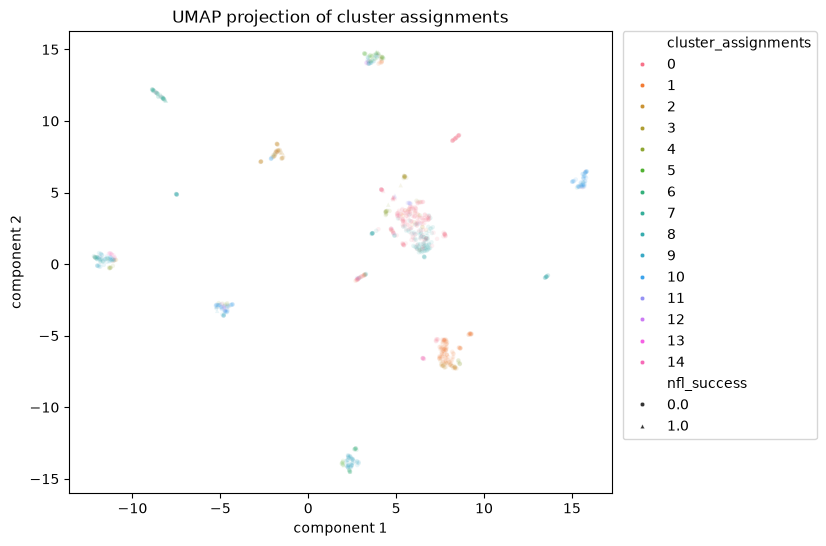

In [17]:
cluster_data = clustering.run_agglomerative(cluster_data.drop(columns='cluster_assignments'), n_clusters=15)
print(cluster_data.loc[:, ['cluster_assignments', 'nfl_success']].value_counts().sort_index(level=0))
viz.plot_cluster_assignments(embedding, cluster_data['cluster_assignments'])
plt.show()

A few clusters stand out with a higher proportion of successful QBs, but not dramatically so. I'll try spectral clustering next to see if it does better.

cluster_assignments  nfl_success
0                    0.0             60
                     1.0              1
1                    0.0             61
2                    0.0             84
3                    0.0             66
                     1.0              1
4                    0.0             54
                     1.0              2
5                    0.0             70
                     1.0              1
6                    0.0             82
7                    0.0             41
8                    0.0             66
                     1.0              1
9                    0.0            106
10                   0.0             23
11                   0.0            147
12                   0.0              3
                     1.0             31
13                   0.0            112
14                   0.0             34
Name: count, dtype: int64


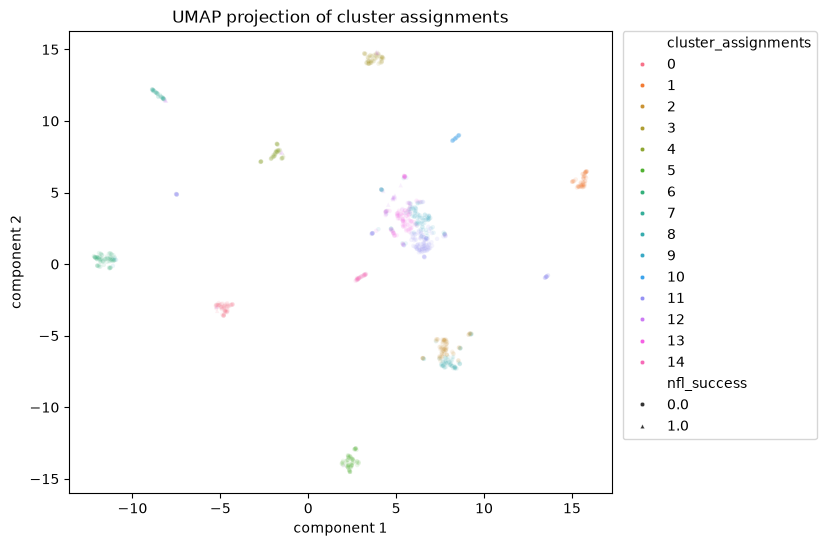

In [18]:
cluster_data = clustering.run_spectral_clustering(cluster_data.drop(columns='cluster_assignments'), n_clusters=15, n_neighbors=50, random_state=0)
print(cluster_data.loc[:, ['cluster_assignments', 'nfl_success']].value_counts().sort_index(level=0))
viz.plot_cluster_assignments(embedding, cluster_data['cluster_assignments'])
plt.show()

Cluster 12 looks very promising — roughly 91% of the players in that cluster were successful, and it contains the large majority of all successful QBs in the dataset. The clusters are also much more clearly separated in this projection than with agglomerative clustering. Below I dig into cluster 12 specifically.

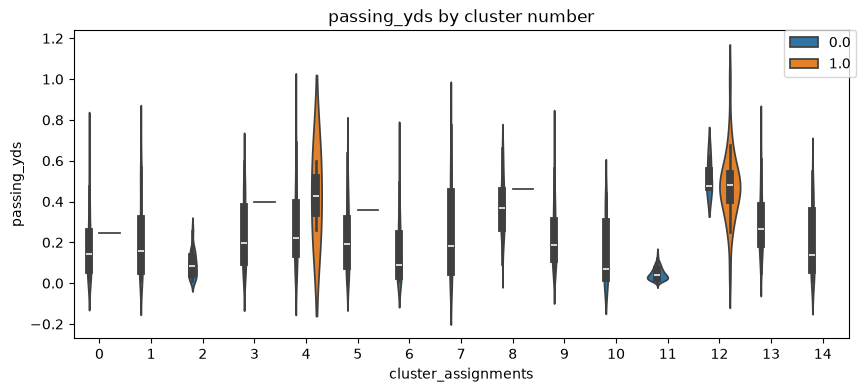

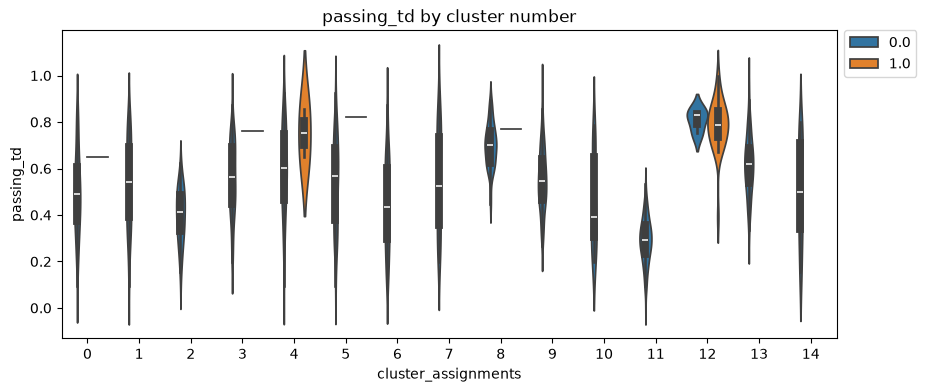

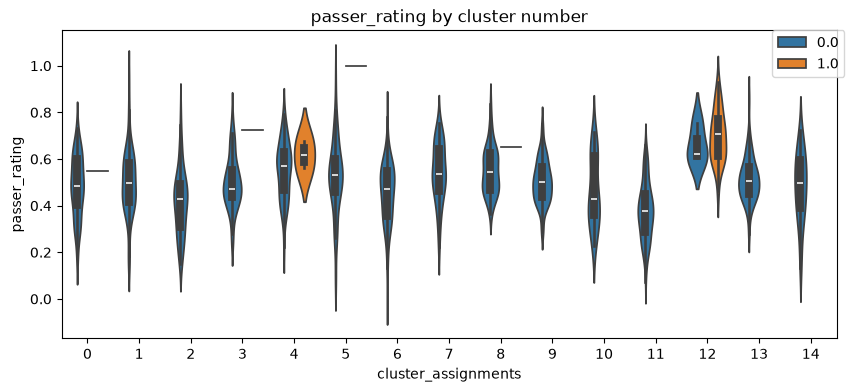

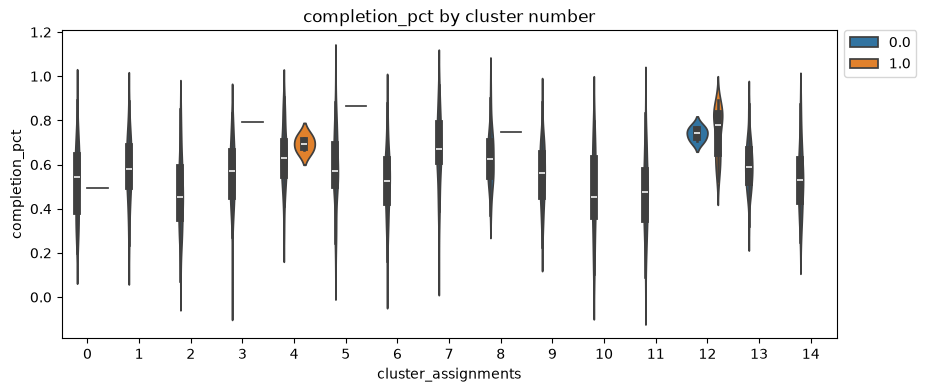

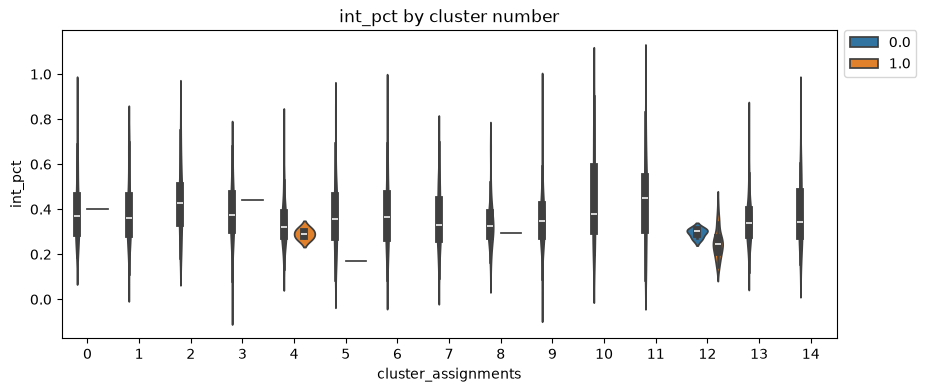

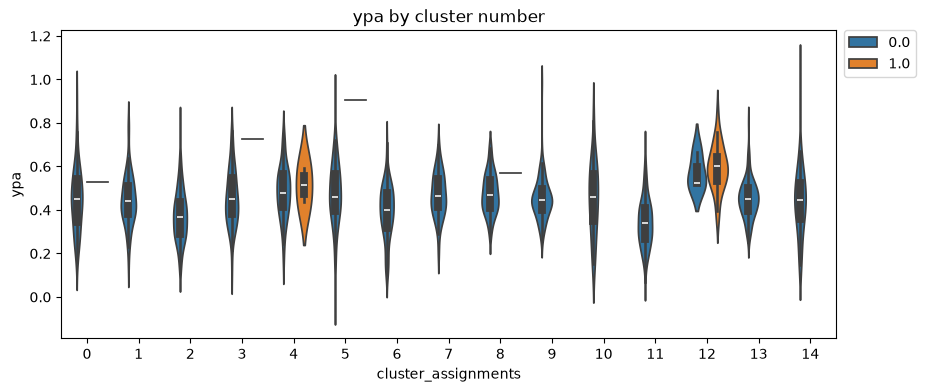

In [19]:
plot_columns = ['passing_yds', 'passing_td', 'passer_rating', 'completion_pct', 'int_pct', 'ypa']
for factor in plot_columns:
    viz.plot_clusters_by_factor(cluster_data, factor=factor)
    plt.show()

Players in cluster 12 are noticeably higher in nearly every stat shown here, outside of interception percentage (lower is better). These look like high performers overall. There are so few unsuccessful players in the cluster that it's hard to draw conclusions from the spread within it.

In [20]:
important_differences = clustering.cluster_feature_differences(cluster_data, target_cluster=12, threshold=0.15)
important_differences

,target_cluster,other_clusters,difference
passing_completions,0.740523,0.448554,0.291969
passing_td,0.787440,0.503867,0.283573
passing_yds,0.480639,0.199898,0.280741
passing_att,0.491560,0.224145,0.267415
rushing_td,0.593447,0.369812,0.223635
passer_rating,0.693170,0.481110,0.212060
completion_pct,0.744460,0.549786,0.194674
td_pct,0.542764,0.365597,0.177167
ypa,0.591188,0.431422,0.159765
rushing_car,0.662511,0.503131,0.159380


Comparing cluster 12's mean stats against every other cluster (keeping any feature with at least a 15% absolute difference), it's not surprising which columns show up — these are statistics you'd expect top quarterbacks to lead in. What's more interesting is what's *not* on the list: interceptions and interception percentage aren't among the most significant differences, and rushing yards isn't either even though rushing touchdowns and carries are. That would change how I'd evaluate a quarterback who takes a lot of risks and racks up some negative plays — I'd be more willing to overlook that in favor of strong overall production.

In [21]:
cluster_data_with_ids = pd.concat([athlete_ids.reset_index(drop=True), cluster_data.reset_index(drop=True)], axis=1)
cluster_12_ids = cluster_data_with_ids.loc[cluster_data_with_ids['cluster_assignments'] == 12, 'athlete_id']
cluster_12_info = cfb_nfl_dataset[cfb_nfl_dataset['athlete_id'].isin(cluster_12_ids)][['athlete_id', 'Clean_Name', 'AV', 'Round']]
cluster_12_info.sort_values(by='AV', ascending=False)

,athlete_id,Clean_Name,AV,Round
182,238093,russell wilson,188.0,3
416,484080,derek carr,119.0,2
66,183253,andy dalton,118.0,2
1435,3916387,lamar jackson,114.0,1
1032,547401,jared goff,113.0,1
637,512030,dak prescott,112.0,4
1080,550373,baker mayfield,81.0,1
238,380470,andrew luck,80.0,1
1448,3917315,kyler murray,77.0,1
1656,4040715,jalen hurts,75.0,2


This is exactly the kind of result I was looking for. Of the QBs in this cluster, most were drafted in the first round, as you'd expect for a blue-chip prospect — but several slipped to the second, third, or later rounds. A team that could identify a QB who fits this profile but has been missed by other teams could find real value. The handful of unsuccessful QBs in the cluster are interesting too; it would be worth studying those negative results specifically, since there are plenty of intangible reasons a player can fail in the NFL that wouldn't show up in this data.

I'll try OPTICS next, first on cluster 12 alone to see if it splits into smaller, more cohesive groups.

In [22]:
cluster_12_data = cluster_data_with_ids[cluster_data_with_ids['cluster_assignments'] == 12].drop(columns=['athlete_id', 'cluster_assignments'])
optics_12 = clustering.run_optics(cluster_12_data, min_samples=4)
print(optics_12.loc[:, ['cluster_assignments', 'nfl_success']].value_counts().sort_index(level=0))

cluster_assignments  nfl_success
-1                   1.0            10
 0                   0.0             3
                     1.0            16
 1                   1.0             5
Name: count, dtype: int64


The cluster is too small for OPTICS to return anything meaningful. I'll try OPTICS on the full dataset instead, to see if it finds something spectral clustering didn't.

cluster_assignments  nfl_success
-1                   0.0            728
                     1.0             37
 0                   0.0             14
 1                   0.0             11
 2                   0.0             10
 3                   0.0             10
 4                   0.0             22
 5                   0.0             10
 6                   0.0             39
 7                   0.0             31
 8                   0.0             14
 9                   0.0             11
 10                  0.0             45
 11                  0.0             37
 12                  0.0             27
Name: count, dtype: int64


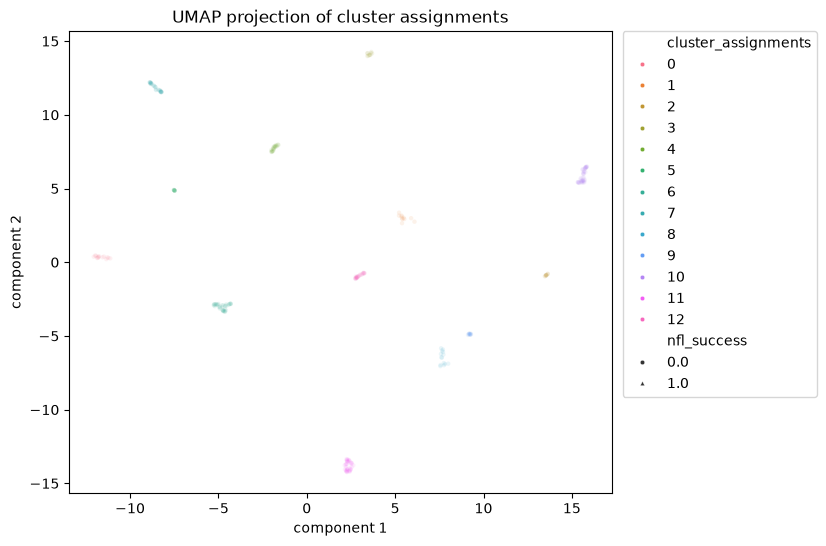

In [23]:
optics_full = clustering.run_optics(cluster_data.drop(columns='cluster_assignments'), min_samples=10)
print(optics_full.loc[:, ['cluster_assignments', 'nfl_success']].value_counts().sort_index(level=0))

cluster_temp = optics_full[optics_full['cluster_assignments'] > -1]
viz.plot_cluster_assignments(embedding, cluster_temp['cluster_assignments'])
plt.show()

I tried several values of `min_samples` and all of them push the successful quarterbacks into the noise cluster (`-1`). There are simply too few positive examples, and they're too spread out, for OPTICS to work well here. I'll move on to similarity search and keep the spectral clustering results for the conclusion.

# 7.0 Similarity Search

Because the dataset is small (about 1,000 QBs), a flat index is fast enough and gives exact (100% recall) nearest-neighbor results — no need for an approximate index.

In [24]:
similarity_index = similarity.build_similarity_index(standard_data)

feature_data = standard_data.drop(columns=['athlete_id', 'nfl_success']).values.astype('float32')
distances, indices = similarity_index.search(feature_data[0:1], k=5)
print('Similar indices:', indices)
print('Distances:', distances)

Similar indices: [[  0 844 990 479 483]]
Distances: [[0.         0.05944252 0.24136579 0.8254471  0.8290068 ]]


The first two neighbors here are reasonably close, then there's a drop-off in quality.

In [25]:
top_five_ids = standard_data.iloc[indices[0]]['athlete_id']
cfb_nfl_dataset[cfb_nfl_dataset['athlete_id'].isin(top_five_ids)][['athlete_id', 'Clean_Name', 'AV', 'Round']].sort_values(by='AV', ascending=False)

,athlete_id,Clean_Name,AV,Round
0,132870,martevious young,0.0,NaN
843,531770,anthony alford,0.0,NaN
849,532089,cole weeks,0.0,NaN
1639,4039275,kwadra griggs,0.0,NaN
2018,4362942,tate whatley,0.0,NaN


The actual players here are QBs I'd never heard of, with no real draft buzz — searching from row 0 isn't a very informative example. `qb_similarity.similarity.find_similar_players` makes it easy to search by name instead, which is much more useful for spot-checking the model against known prospects.

In [26]:
similarity.find_similar_players('trevor lawrence', cfb_nfl_dataset, standard_data, similarity_index)

,athlete_id,Clean_Name,AV,Round,distance
0,4360310.0,trevor lawrence,41.0,1,0.000000
1,3916387.0,lamar jackson,114.0,1,1.499123
2,4037213.0,jamie newman,0.0,NaN,1.566782
3,3124900.0,jake luton,2.0,6,2.346297
4,3915511.0,joe burrow,63.0,1,2.384313


This is an interesting group. Lawrence is one of the best QB prospects of his generation. He's grouped with Lamar Jackson and Joe Burrow — two of the other best college QBs of the last 25 years — alongside a couple of relatively obscure players.

In [27]:
similarity.find_similar_players('josh allen', cfb_nfl_dataset, standard_data, similarity_index)

,athlete_id,Clean_Name,AV,Round,distance
0,3918298.0,josh allen,112.0,1,0.000000
1,4036378.0,jordan love,30.0,1,1.531212
2,511889.0,jeff driskel,8.0,6,2.487679
3,4038220.0,cole mcdonald,0.0,NaN,2.528687
4,160307.0,max hall,1.0,Undrafted,2.540103


Josh Allen was a much more polarizing prospect, and here he's grouped with Jordan Love, who was viewed similarly coming out of college. The knock on Allen was that his college stats were mediocre but he had prototypical size — that physical trait isn't reflected in this analysis.

In [28]:
similarity.find_similar_players('josh rosen', cfb_nfl_dataset, standard_data, similarity_index)

,athlete_id,Clean_Name,AV,Round,distance
0,3886377.0,josh rosen,3.0,1,0.000000
1,3912547.0,sam darnold,42.0,1,0.730127
2,547401.0,jared goff,113.0,1,0.774701
3,3915436.0,steven montez,0.0,NaN,0.804127
4,513329.0,cody kessler,5.0,3,0.850550


Josh Rosen is a famous bust — one of the worst in recent memory. Sam Darnold was also widely written off as a bust before a surprising breakout after being cast aside by his original team. Jared Goff was similarly doubted early in his career, then significantly improved after being traded.

In [29]:
similarity.find_similar_players('mac jones', cfb_nfl_dataset, standard_data, similarity_index)

,athlete_id,Clean_Name,AV,Round,distance
0,4241464.0,mac jones,28.0,1,0.000000
1,191494.0,greg mcelroy,1.0,7,0.440208
2,480215.0,aj mccarron,4.0,5,0.841337
3,517475.0,johnny manziel,4.0,1,1.644293
4,4034946.0,kyle trask,0.0,2,1.729417


This is an example of the feature hashing working as intended. Mac Jones played for Alabama in the SEC and wasn't an overwhelming statistical performer. The similarity search returns two other Alabama QBs and four SEC QBs.

# 8.0 Conclusion

I accomplished many of the goals I set out with. I performed a cluster analysis and found a cluster with a high proportion of successful quarterbacks. I built a similarity search function that lets you search for comparable quarterbacks by name. The similarity search lines up reasonably well with what my domain knowledge would suggest.

There were some real limitations to this approach. I would have liked more data, including reliable height/weight and advanced statistics — I believe these would have been valuable, but I couldn't find a public dataset with enough coverage of them. The analysis was also limited by the size of the dataset, even though I was working with the full population of relevant QBs. I could have included quarterbacks from further back, but the game has changed enough since the '90s that comparing across that gap doesn't feel reasonable.

If I were to take this further, there are a few things I'd want to add. I'd like to capture data points about the college teams themselves — offensive scheme, team quality, and quality of competition are likely big indicators of future success. Some of that is probably already captured indirectly through the feature-hashing of conference and college team, but I'd like to analyze those factors directly. I'd also like to analyze combine-invited athletes separately and fold that back into the college data analysis. Finally, a related but separate question I'd like to pursue is the "nature vs. nurture" debate: do quarterbacks succeed or fail based on their own skill, or on the quality of the situation they're drafted into? Combining this college-data analysis with an analysis of the NFL teams themselves could help investigate that.

In the end, I gleaned some genuinely interesting insights. I located a cluster that was about 91% made up of successful quarterbacks, and found that passing volume mattered more than efficiency for that cluster. I was also surprised to find that interceptions weren't among the most significant differences for that cluster. I also built a similarity search function I can keep using and extending in future draft analysis — and with more data, I think it could get even better.

# Appendix

## Column explanations
1. **athlete_id**: A unique ID returned by the R package used to pull the college data.
2. **passing_completions**: The number of passes thrown by the quarterback that were caught by a receiver.
3. **passing_att**: The number of passes thrown by the quarterback.
4. **passing_yds**: The number of yards thrown by the quarterback. Upon a completed pass, a quarterback is credited with the yards gained from the line of scrimmage to where the receiver is tackled or scores.
5. **passing_td**: The number of touchdowns thrown by the quarterback.
6. **passing_int**: The number of passes thrown by the quarterback that were caught by a defender (lower is better).
7. **rushing_car**: The number of times the quarterback ran with the ball. For college stats, sacks are included in this number.
8. **rushing_yds**: The number of yards the quarterback gained running, relative to the line of scrimmage. Since sacks are included, negative values are possible.
9. **rushing_td**: The number of touchdowns a quarterback scored by rushing.
10. **rushing_long**: The longest run, relative to the line of scrimmage, the quarterback achieved in their career.
11. **from_year**: The first college season the quarterback recorded a statistic.
12. **to_year**: The final college season the quarterback recorded a statistic.
13. **college_team**: The college(s) the quarterback played for.
14. **conference**: The conference(s) the quarterback played in. A conference is a grouping of teams that play most of their games against each other — originally grouped by proximity and competitiveness, but increasingly driven by television revenue.
15. **completion_pct**: The percentage of passes caught by a receiver. Used to measure accuracy.
16. **ypa**: Yards per pass attempt. Used to measure how aggressive a quarterback is.
17. **td_pct**: Touchdowns per attempt.
18. **int_pct**: Interceptions per attempt (lower is better).
19. **ypr**: Yards per rush.
20. **passer_rating**: A commonly used calculation of overall efficiency that combines the four rate stats above (#15–18). See [this link](https://en.wikipedia.org/wiki/Passer_rating) for the calculation and its history.
21. **Clean_Name**: The quarterback's name, standardized for matching across datasets.
22. **AV**: See the link in Section 2.0 Data.
23. **Draft Team**: The NFL team that drafted the quarterback, if applicable.
24. **Round**: The round of the NFL draft the quarterback was selected in, if applicable (1–7, or undrafted).
25. **Pick**: The pick number the quarterback was selected at, if applicable (1 at minimum; the maximum varies by year but is always between roughly 250 and 270).
26. **Draft Year**: The year the quarterback was drafted, if applicable.
27. **from_year_nfl**: The first year the quarterback recorded an NFL statistic.
28. **to_year_nfl**: The final year the quarterback recorded an NFL statistic.
29. **draft_age**: The quarterback's age when drafted.
30. **G**: NFL games played.
31. **GS**: NFL games played as the starting quarterback.
32. **nfl_team**: The NFL team the quarterback played for in his final NFL season.
33. **years_played**: Total years played in the NFL.
34. **av_per_year**: AV divided by years played.

## Citations
1. ChatGPT query: "How do I aggregate a column when grouping rows in a pandas dataframe by a unique ID that has multiple values per ID? I want to keep each value and alphabetize it, separated by commas." Informed the `team`/`conference` aggregation in `src/qb_similarity/cleaning.py`.
2. ChatGPT query: "How do I split a height string in the format '6-0' into numbers that I can convert to inches?" Informed `height_to_inches` in `src/qb_similarity/features.py`.
3. ChatGPT query: "What is a numpy function I can use to combine two feature-hashed arrays for PCA dimensionality reduction?" Informed `np.hstack` usage in `src/qb_similarity/features.py`.